# Iris Decision Tree Classifier

Trains a decision tree to classify iris flowers into one of three species (0, 1, 2) based on sepal/petal length and width.

**Dataset:** `Iris.csv`
**Columns:** `Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. Load data

In [2]:
# NOTE: update this path if running outside this environment.
DATA_PATH = "Iris.csv"

df = pd.read_csv(DATA_PATH)
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,1
1,2,4.9,3.0,1.4,0.2,1
2,3,4.7,3.2,1.3,0.2,1
3,4,4.6,3.1,1.5,0.2,1
4,5,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [3]:
df.shape

(150, 6)

In [4]:
df.columns.tolist()

['Id',
 'SepalLengthCm',
 'SepalWidthCm',
 'PetalLengthCm',
 'PetalWidthCm',
 'Species']

In [5]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species            int64
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 7.2 KB


In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667,1.000000
std,43.445368,0.828066,0.433594,1.764420,0.763161,0.819232
min,1.000000,4.300000,2.000000,1.000000,0.100000,0.000000
25%,38.250000,5.100000,2.800000,1.600000,0.300000,0.000000
50%,75.500000,5.800000,3.000000,4.350000,1.300000,1.000000
75%,112.750000,6.400000,3.300000,5.100000,1.800000,2.000000
max,150.000000,7.900000,4.400000,6.900000,2.500000,2.000000


In [8]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Species"].value_counts()

Species
1    50
0    50
2    50
Name: count, dtype: int64

## 2. Features / target

Drop the `Id` column explicitly (rather than slicing by position) so the notebook doesn't silently break if column order ever changes.

In [11]:
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
target_col = "Species"

x = df[feature_cols].values
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [12]:
y = df[target_col].values
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## 3. Train/test split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=0, stratify=y
)
# stratify=y keeps the 50/50/50 class balance in both splits -- worth doing
# here since the classes are small and evenly sized to begin with.

## 4. Feature scaling

Standardization isn't strictly necessary for decision trees (they're scale invariant), but kept here to mirror the original script's structure. Feel free to drop this step for trees — it matters more for distance-based models (KNN, SVM) or linear models.

In [14]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [15]:
X_train

array([[-5.36904878e-01,  1.53536534e+00, -1.30187254e+00,
        -1.31836272e+00],
       [ 6.17286030e-01,  3.59162070e-01,  3.93589371e-01,
         3.77340566e-01],
       [ 8.48124212e-01, -3.46559892e-01,  4.50104768e-01,
         1.16463138e-01],
       [-9.98581241e-01,  1.06488403e+00, -1.24535714e+00,
        -7.96607861e-01],
       [-1.11400033e+00, -1.28752251e+00,  3.93589371e-01,
         6.38217994e-01],
       [ 5.01866939e-01, -1.28752251e+00,  6.76166355e-01,
         8.99095422e-01],
       [-1.11400033e+00,  1.23921416e-01, -1.30187254e+00,
        -1.44880143e+00],
       [-4.21485787e-01, -1.05228186e+00,  3.37073974e-01,
        -1.39755765e-02],
       [-8.83162150e-01,  5.94402725e-01, -1.18884174e+00,
        -9.27046575e-01],
       [-9.98581241e-01, -1.75800382e+00, -2.84595391e-01,
        -2.74853005e-01],
       [-3.06066696e-01, -3.46559892e-01, -1.15049201e-01,
         1.16463138e-01],
       [-8.83162150e-01,  1.77060600e+00, -1.30187254e+00,
      

In [16]:
X_test

array([[-0.42148579, -1.28752251,  0.11101239,  0.11646314],
       [ 0.15560967, -1.99324447,  0.11101239, -0.274853  ],
       [-0.88316215, -1.28752251, -0.45414158, -0.14441429],
       [ 0.27102876, -0.58180055,  0.50662016, -0.01397558],
       [-0.53690488,  0.82964338, -1.30187254, -1.05748529],
       [-0.53690488,  2.00584665, -1.18884174, -1.05748529],
       [-0.99858124,  0.59440272, -1.35838793, -1.31836272],
       [-0.76774306, -0.8170412 ,  0.05449699,  0.24690185],
       [-0.99858124,  0.35916207, -1.47141873, -1.31836272],
       [ 1.54063876, -0.11131924,  1.12828953,  0.50777928],
       [ 0.50186694,  0.59440272,  1.24132032,  1.68172771],
       [-0.3060667 , -0.58180055,  0.61965096,  1.02953414],
       [-0.88316215,  1.06488403, -1.35838793, -1.187924  ],
       [ 0.50186694, -0.34655989,  1.01525874,  0.76865671],
       [-0.88316215,  0.82964338, -1.30187254, -1.31836272],
       [ 0.27102876, -0.58180055,  0.11101239,  0.11646314],
       [-0.42148579, -1.

## 5. Train decision tree

In [17]:
from sklearn.tree import DecisionTreeClassifier

# max_depth caps tree growth to reduce overfitting -- Iris is small and
# well-separated, so a shallow tree (3-4) usually classifies it cleanly
# without memorizing noise. Set to None for an unconstrained tree.
classifier = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=0)
classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

## 6. Predict & evaluate

In [18]:
y_pred = classifier.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 2, 2, 1, 2, 1, 0, 0, 2, 0, 1, 2, 1,
       1, 0, 2, 0, 0, 1, 2, 1, 0, 1, 2, 2, 0, 1, 2, 2])

In [19]:
y_test

array([0, 0, 0, 0, 1, 1, 1, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0, 1, 2, 1,
       1, 0, 2, 0, 0, 1, 2, 1, 0, 1, 2, 2, 0, 1, 2, 2])

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import metrics

cm = confusion_matrix(y_test, y_pred)
cm

array([[13,  0,  0],
       [ 0, 13,  0],
       [ 1,  0, 11]])

In [21]:
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 97.37%


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      1.00      1.00        13
           2       1.00      0.92      0.96        12

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



## 7. Predict a new sample

**Note:** the numeric `Species` codes in this file are **not** in standard alphabetical order. Verified against this file's actual per-class petal-length averages (setosa ~1.5cm, versicolor ~4.3cm, virginica ~5.6cm) rather than assumed.

In [23]:
species_names = {0: "Iris-versicolor", 1: "Iris-setosa", 2: "Iris-virginica"}

new_flower = np.array([[5.8, 3.0, 4.5, 1.5]])  # sepal_len, sepal_wid, petal_len, petal_wid
new_flower_scaled = sc_X.transform(new_flower)
prediction = classifier.predict(new_flower_scaled)
print(f"Predicted species: {species_names[prediction[0]]}")

Predicted species: Iris-versicolor


## 8. Visualize the tree

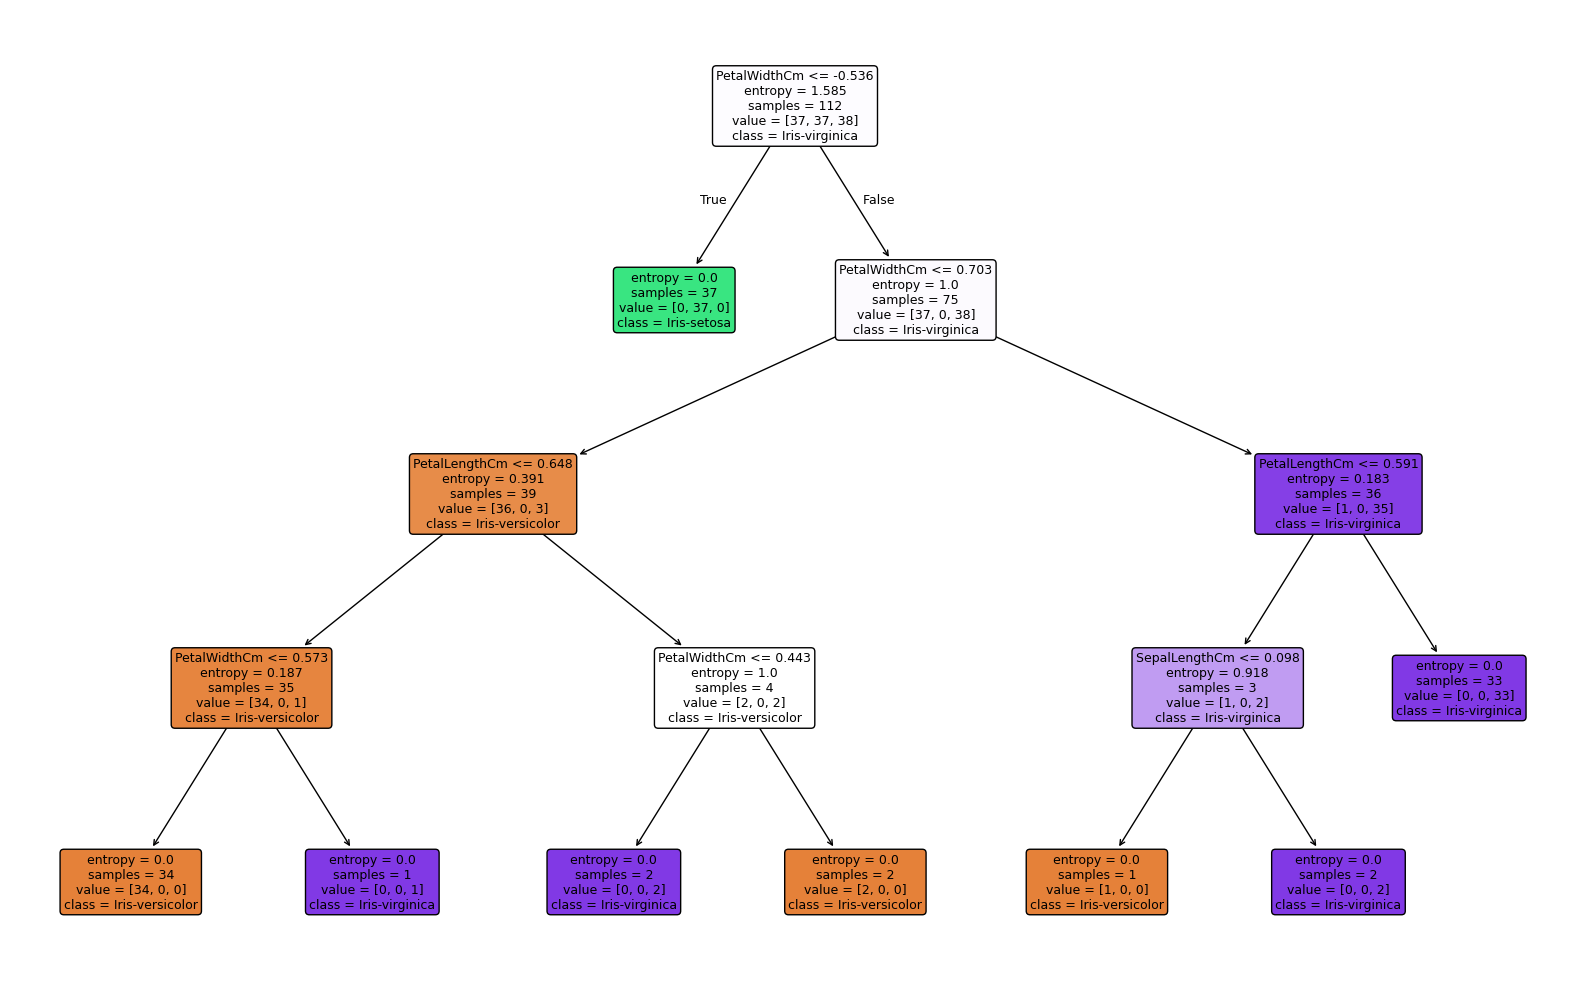

In [24]:
from sklearn import tree

plt.figure(figsize=(16, 10))
tree.plot_tree(
    classifier,
    feature_names=feature_cols,
    class_names=list(species_names.values()),
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.tight_layout()
plt.savefig("iris_tree.png", dpi=150)
plt.show()